## Test test

In [1]:
# setup imports
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

PROJECT_ROOT = Path().resolve().parents[2]  # pas aan als notebook dieper/dichter zit
sys.path.append(str(PROJECT_ROOT))

In [2]:
import pickle
import warnings
from pathlib import Path

import seaborn as sns

from src.models import *
from src.paths import *

warnings.filterwarnings("ignore", category=UserWarning)

/opt/conda/envs/ewatercycle2/lib/python3.12/site-packages/esmvalcore/experimental/_warnings.py:13: UserWarning: 
  Thank you for trying out the new ESMValCore API.
  Note that this API is experimental and may be subject to change.
  More info: https://github.com/ESMValGroup/ESMValCore/issues/498


In [3]:
results_folder = Path("results_chatly_1")
result_files = list(results_folder.glob("result_seed_*.pkl"))

loaded_results = []
for f in result_files:
    with open(f, "rb") as file:
        res = pickle.load(file)
        loaded_results.append(res)

# Example: print best objective per seed
for r in loaded_results:
    print(f"Seed {r['seed']}: best_f = {r['best_f']}, nfev = {r['nfev']}")

Seed 555666: best_f = 0.20882555232619954, nfev = 256
Seed 445566: best_f = 0.2101244658639899, nfev = 256
Seed 111222: best_f = 0.21690286823665925, nfev = 256
Seed 987654: best_f = 0.2198063319173112, nfev = 256
Seed 654321: best_f = 0.21093658616308006, nfev = 256
Seed 112233: best_f = 0.22494180137394132, nfev = 256
Seed 999000: best_f = 0.21313155239451193, nfev = 256
Seed 777888: best_f = 0.2198141636677632, nfev = 256
Seed 214025: best_f = 0.21536909386941755, nfev = 256
Seed 180988: best_f = 0.21706185785649468, nfev = 256
Seed 333444: best_f = 0.2310312806435487, nfev = 256
Seed 123456: best_f = 0.23411729576683066, nfev = 256


In [4]:
best_params_list = []

for run_idx, run in enumerate(loaded_results):
    seed = run["seed"]
    history = run["history"]

    # find the best evaluation by objective value
    best_idx = np.argmin(history["objective"])

    best_theta_phys = history["theta_phys"][best_idx]
    best_obj = history["objective"][best_idx]
    best_nse = history["nse"][best_idx]
    best_kge = history["kge"][best_idx]
    best_vol_err = history["vol_err"][best_idx]

    row = {
        "seed": seed,
        "best_eval": best_idx + 1,
        "objective": best_obj,
        "nse": best_nse,
        "kge": best_kge,
        "vol_err": best_vol_err,
    }

    # add each parameter with its proper name
    for i, th in enumerate(best_theta_phys):
        row[parameter_names[i]] = th

    best_params_list.append(row)

# create DataFrame
best_params_df = pd.DataFrame(best_params_list)
best_params_df

best_params_df.to_pickle("best_params_df_TA.pkl")

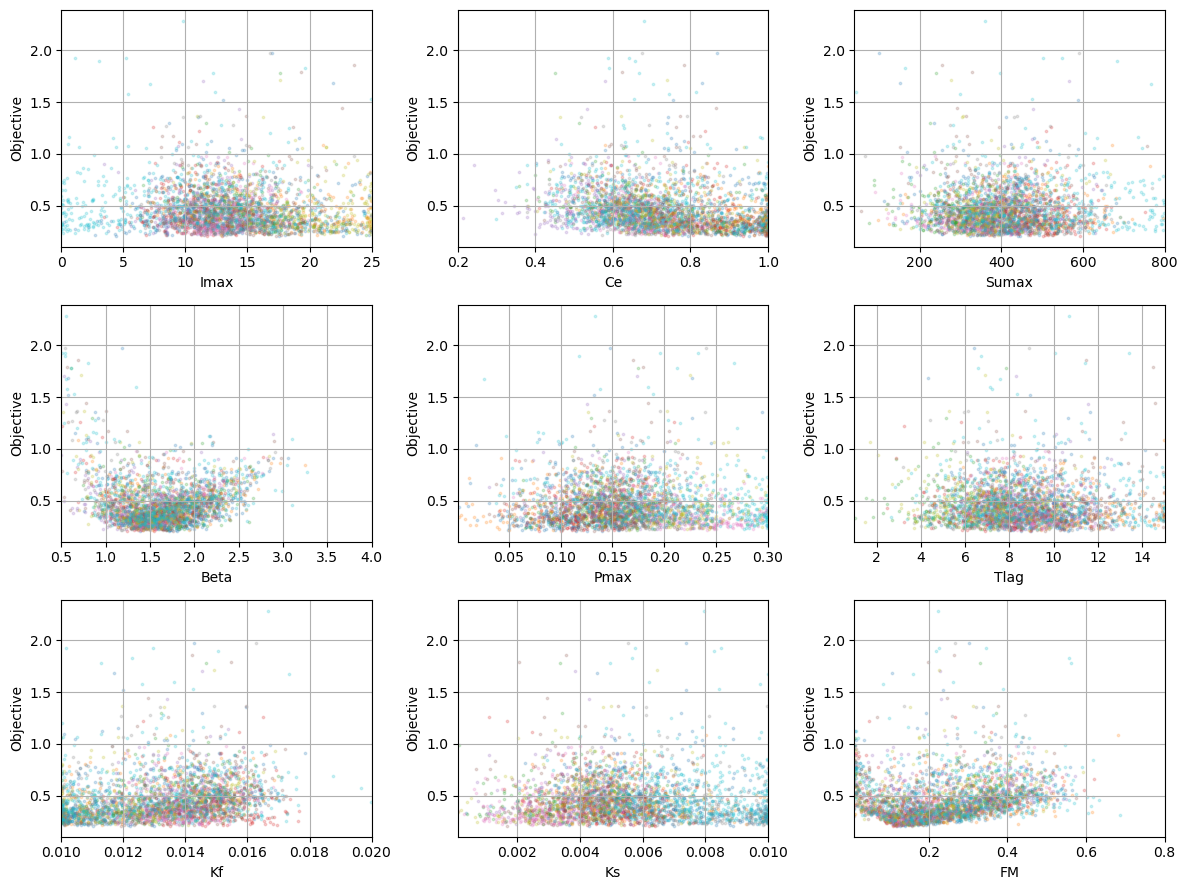

In [5]:
import numpy as np
import pandas as pd

# Suppose you have multiple seeds in `results`:
dfs = []
for seed_idx, res_seed in enumerate(loaded_results):
    hist = res_seed["history"]
    df = pd.DataFrame(hist)
    df["seed"] = seed_idx  # add a seed column
    dfs.append(df)

history_df = pd.concat(dfs, ignore_index=True)

n_params = len(p_min)  # 9
seeds = history_df["seed"].unique()  # get all unique seeds
colors = plt.cm.tab10(np.linspace(0, 1, len(seeds)))  # assign colors

n_cols = 3
n_rows = int(np.ceil(n_params / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(4 * n_cols, 3 * n_rows))
axes = axes.flatten()  # flatten for easy indexing

for i in range(n_params):
    ax = axes[i]

    for seed, color in zip(seeds, colors):
        theta_array = np.stack(history_df.loc[history_df["seed"] == seed, "theta_phys"].values)
        obj_array = history_df.loc[history_df["seed"] == seed, "objective"].values
        ax.scatter(theta_array[:, i], obj_array, label=f"Seed {seed}", color=color, alpha=0.2, s=3)
        ax.set_xlabel(parameter_names[i])

    ax.set_ylabel("Objective")
    # ax.set_title()
    ax.set_xlim(p_min[i], p_max[i])
    ax.grid(True)

# remove empty axes
for j in range(n_params, len(axes)):
    fig.delaxes(axes[j])


# axes[0].legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

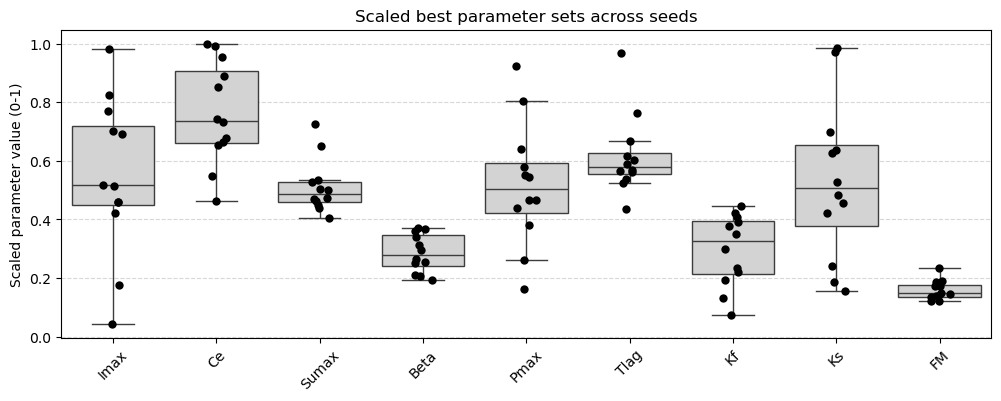

In [6]:
# Parameter columns
param_cols = ["Imax", "Ce", "Sumax", "Beta", "Pmax", "Tlag", "Kf", "Ks", "FM"]

# Scale the best parameters
scaled_params_df = pd.DataFrame(scale(best_params_df[param_cols].to_numpy()), columns=param_cols)


plt.figure(figsize=(12, 4))
# sns.boxplot(data=scaled_params_df, color = 'lightgray')
# sns.stripplot(data=scaled_params_df, color='black', jitter=False, size=8)
sns.boxplot(
    data=scaled_params_df, color="lightgray", fliersize=0
)  # light gray boxes, hide default outliers
sns.stripplot(data=scaled_params_df, color="black", jitter=True, size=6, marker="o")  # black dots

plt.xticks(rotation=45)
plt.ylabel("Scaled parameter value (0-1)")
plt.title("Scaled best parameter sets across seeds")
# add horizontal grid lines
plt.grid(axis="y", linestyle="--", alpha=0.5)

plt.show()

In [7]:
rows = []

for run_idx, run in enumerate(loaded_results):
    seed = run["seed"]
    history = run["history"]

    n_eval = len(history["objective"])

    for i in range(n_eval):
        row = {
            "seed": seed,
            "eval": i + 1,
            "objective": history["objective"][i],
            "nse": history["nse"][i],
            "kge": history["kge"][i],
            "vol_err": history["vol_err"][i],
        }

        # parameters
        for j, th in enumerate(history["theta_phys"][i]):
            row[parameter_names[j]] = th

        rows.append(row)

all_results_df = pd.DataFrame(rows)
best_row = all_results_df.loc[all_results_df["objective"].idxmin()]

print(best_row)

seed         555666.000000
eval             91.000000
objective         0.208826
nse               0.598663
kge               0.708818
vol_err           0.002675
Imax             17.553422
Ce                0.793850
Sumax           445.949088
Beta              1.383536
Pmax              0.140063
Tlag              8.537393
Kf                0.012999
Ks                0.007007
FM                0.118738
Name: 90, dtype: float64


In [8]:
q = 0.02  # best 5%
threshold = all_results_df["objective"].quantile(q)

best_5pct_df = all_results_df[all_results_df["objective"] <= threshold].sort_values("objective")

In [9]:
len(best_5pct_df), len(all_results_df)

(62, 3072)

In [10]:
best_5pct_df["seed"].value_counts()

seed
445566    12
654321    10
999000     7
214025     7
777888     7
555666     5
111222     4
180988     3
987654     3
112233     3
333444     1
Name: count, dtype: int64

In [11]:
# 1. Make a copy of describe
desc_fixed = best_params_df[parameter_names].describe()

# 2. Convert count to int
desc_fixed.loc["count"] = desc_fixed.loc["count"].apply(int)

# 3. Round other stats
desc_fixed.loc[desc_fixed.index != "count"] = desc_fixed.loc[desc_fixed.index != "count"].round(3)

# 4. Set index name
desc_fixed.index.name = "Statistic"

# 5. Rename the problematic row labels (the index)
desc_fixed = desc_fixed.rename(index={"25%": "Q25", "50%": "Median", "75%": "Q75"})

# 6. Export to LaTeX
latex_table = desc_fixed.to_latex(
    index=True,
    float_format="%.3f",
    caption="Summary statistics of calibrated parameters",
    label="tab:param_summary",
    escape=False,  # safe since we removed problematic % signs
)

# 7. Write to file
with open("parameter_summary.tex", "w") as f:
    f.write(latex_table)

print("LaTeX table saved as 'parameter_summary.tex'")

LaTeX table saved as 'parameter_summary.tex'


In [12]:
print(desc_fixed.index)

Index(['count', 'mean', 'std', 'min', 'Q25', 'Median', 'Q75', 'max'], dtype='object', name='Statistic')


In [13]:
best_5pct_df[parameter_names].describe()

,Imax,Ce,Sumax,Beta,Pmax,Tlag,Kf,Ks,FM
count,62.000000,62.000000,62.000000,62.000000,62.000000,62.000000,62.000000,62.000000,62.000000
mean,14.104066,0.834711,404.492691,1.559961,0.146443,8.996761,0.012699,0.005397,0.149308
std,4.930180,0.139393,75.381745,0.233380,0.057752,1.649822,0.001846,0.002262,0.044635
min,2.690170,0.398657,255.023219,0.965247,0.040381,5.870909,0.010074,0.001520,0.106481
25%,11.466889,0.734703,350.603752,1.386158,0.103714,8.027082,0.011030,0.003427,0.123887
50%,13.049194,0.857806,390.529208,1.582379,0.139960,8.741693,0.012749,0.005369,0.142709
75%,17.494395,0.960827,443.276239,1.714855,0.182997,10.168728,0.013877,0.006452,0.160678
max,24.968138,0.999961,592.443142,2.127368,0.285548,13.521915,0.016946,0.009874,0.427503


In [14]:
# Parameter columns
param_cols = ["Imax", "Ce", "Sumax", "Beta", "Pmax", "Tlag", "Kf", "Ks", "FM"]

# Extract parameters as array
theta = best_5pct_df[param_cols].to_numpy()

# Apply your scaling
scaled_theta = scale(theta)

# Back to DataFrame
scaled_params_df = pd.DataFrame(scaled_theta, columns=param_cols)

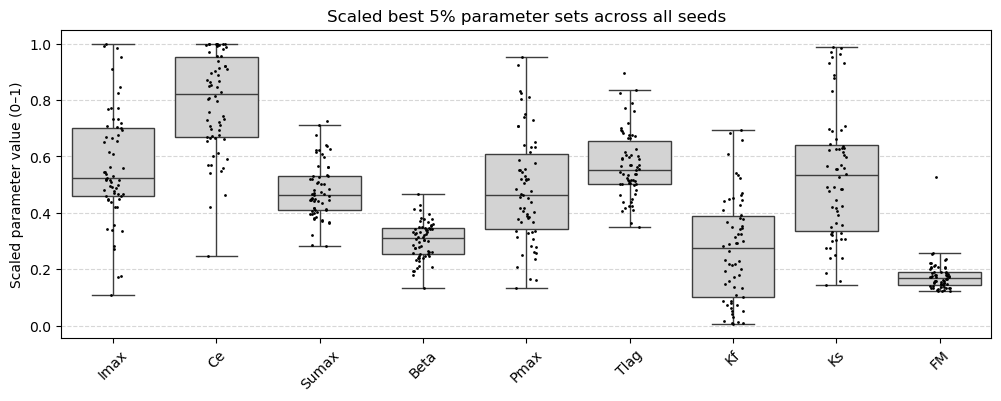

In [15]:
plt.figure(figsize=(12, 4))

sns.boxplot(data=scaled_params_df, color="lightgray", fliersize=0)

sns.stripplot(data=scaled_params_df, color="black", jitter=True, size=2, marker="o")

plt.xticks(rotation=45)
plt.ylabel("Scaled parameter value (0–1)")
plt.title("Scaled best 5% parameter sets across all seeds")

plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.show()

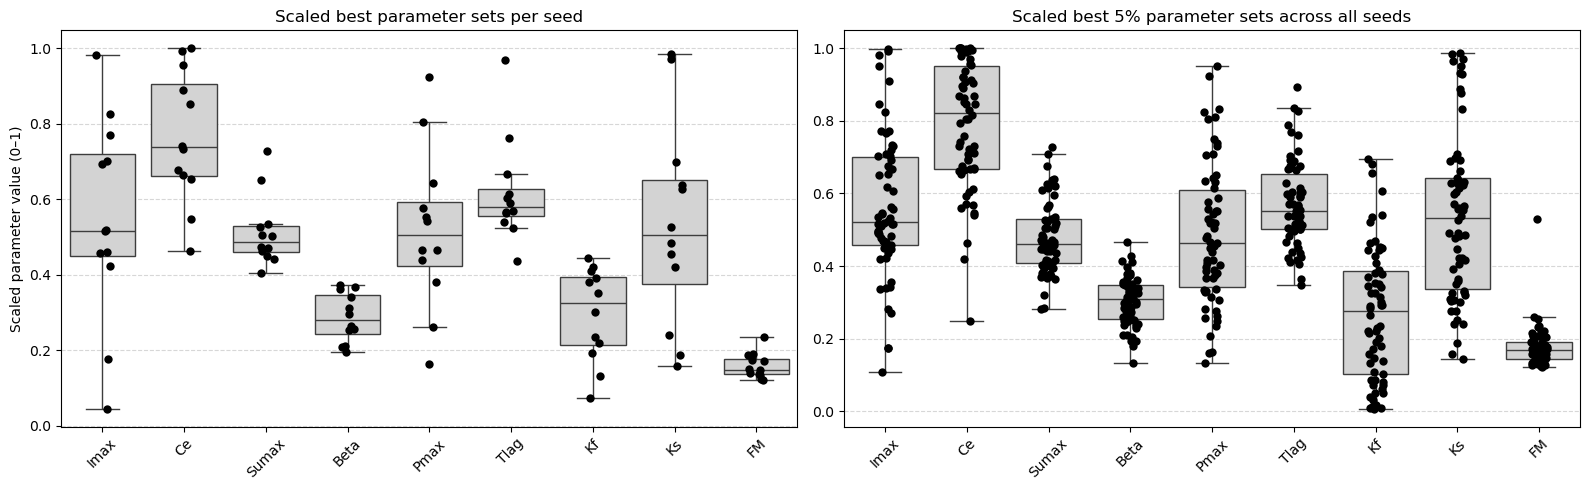

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

# Parameter columns
param_cols = ["Imax", "Ce", "Sumax", "Beta", "Pmax", "Tlag", "Kf", "Ks", "FM"]

# Scale both datasets
scaled_best_per_seed = pd.DataFrame(
    scale(best_params_df[param_cols].to_numpy()), columns=param_cols
)

scaled_best_5pct = pd.DataFrame(scale(best_5pct_df[param_cols].to_numpy()), columns=param_cols)

# Create figure with 2 subplots
plt.figure(figsize=(16, 5))

# Left: best per seed
plt.subplot(1, 2, 1)
sns.boxplot(data=scaled_best_per_seed, color="lightgray", fliersize=0)
sns.stripplot(data=scaled_best_per_seed, color="black", jitter=True, size=6, marker="o")
plt.xticks(rotation=45)
plt.ylabel("Scaled parameter value (0–1)")
plt.title("Scaled best parameter sets per seed")
plt.grid(axis="y", linestyle="--", alpha=0.5)

# Right: top 5%
plt.subplot(1, 2, 2)
sns.boxplot(data=scaled_best_5pct, color="lightgray", fliersize=0)
sns.stripplot(data=scaled_best_5pct, color="black", jitter=True, size=6, marker="o")
plt.xticks(rotation=45)
plt.ylabel("")
plt.title("Scaled best 5% parameter sets across all seeds")
plt.grid(axis="y", linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

In [17]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# Parameter columns
param_cols = ["Imax", "Ce", "Sumax", "Beta", "Pmax", "Tlag", "Kf", "Ks", "FM"]

# Scale both datasets
scaled_best_per_seed = pd.DataFrame(
    scale(best_params_df[param_cols].to_numpy()), columns=param_cols
)
scaled_best_5pct = pd.DataFrame(scale(best_5pct_df[param_cols].to_numpy()), columns=param_cols)

# Add a column to identify the group
scaled_best_per_seed["group"] = "best per seed"
scaled_best_5pct["group"] = f"top {int(100*q)}%"

# Combine both datasets
combined_df = pd.concat([scaled_best_per_seed, scaled_best_5pct], ignore_index=True)

# Melt to long format for seaborn
long_df = combined_df.melt(
    id_vars="group", value_vars=param_cols, var_name="parameter", value_name="scaled_value"
)

In [18]:
long_df["group"].unique()

array(['best per seed', 'top 2%'], dtype=object)

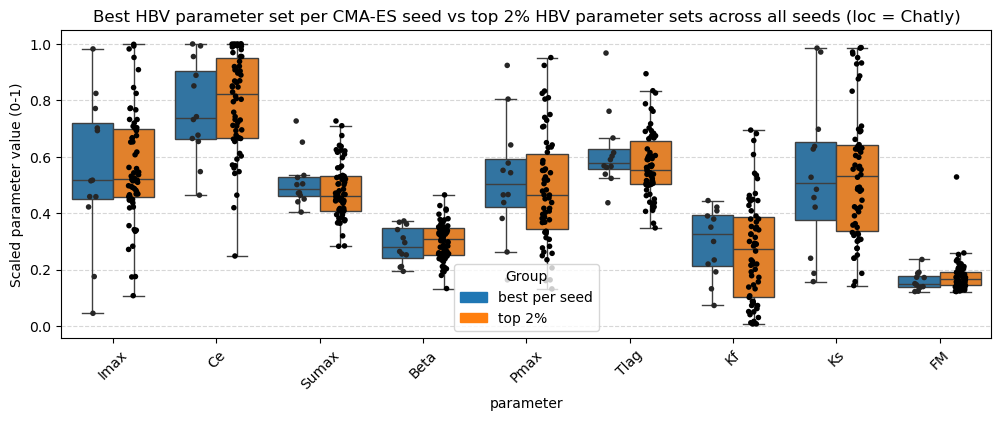

In [19]:
import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 4))

# palette = {
#     'best per seed': 'darkgray',
#     f"top {int(100*q)}%": 'dimgray'
# }

palette = {
    "best per seed": "#1f77b4",  # blue
    f"top {int(100*q)}%": "#ff7f0e",  # orange
}


sns.boxplot(
    data=long_df, x="parameter", y="scaled_value", hue="group", palette=palette, fliersize=0
)

sns.stripplot(
    data=long_df,
    x="parameter",
    y="scaled_value",
    hue="group",
    dodge=True,
    jitter=True,
    size=4,
    marker="o",
    alpha=1,
    palette="dark:black",
    legend=False,  # avoid duplicate legend entries
)

# 3️⃣ Custom legend from boxplot colors only
handles = [mpatches.Patch(color=c, label=l) for l, c in palette.items()]
plt.legend(handles=handles, title="Group")

plt.xticks(rotation=45)
plt.ylabel("Scaled parameter value (0-1)")
plt.title(
    f"Best HBV parameter set per CMA-ES seed vs top {int(100*q)}% HBV parameter sets across all seeds (loc = Chatly)"
)
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.show()

In [20]:
loaded_results

[{'seed': 555666,
  'best_f': 0.20882555232619954,
  'best_x': array([0.70213688, 0.74231267, 0.53414354, 0.25243874, 0.46509428,
         0.53838522, 0.2998993 , 0.69766071, 0.13764253]),
  'nfev': 256,
  'sigma_final': 0.10219044080673448,
  'history': {'theta_norm': [array([0.5717419 , 0.6995145 , 0.54795309, 0.36913226, 0.56976931,
           0.52454908, 0.44166567, 0.49928072, 0.57079356]),
    array([0.47338545, 0.58236775, 0.45969693, 0.49257854, 0.65527308,
           0.44574672, 0.43004377, 0.58115844, 0.56731791]),
    array([0.37981821, 0.41249864, 0.46950856, 0.4482182 , 0.58106644,
           0.39733328, 0.28924708, 0.62407759, 0.6656494 ]),
    array([0.63236541, 0.51230934, 0.39084538, 0.45950742, 0.48393328,
           0.57928865, 0.54357997, 0.60479508, 0.56002857]),
    array([0.45648861, 0.35665752, 0.49528629, 0.35758716, 0.48954923,
           0.47308625, 0.57723278, 0.48595881, 0.42935463]),
    array([0.33999846, 0.36329751, 0.53877842, 0.50747248, 0.46191493,
  

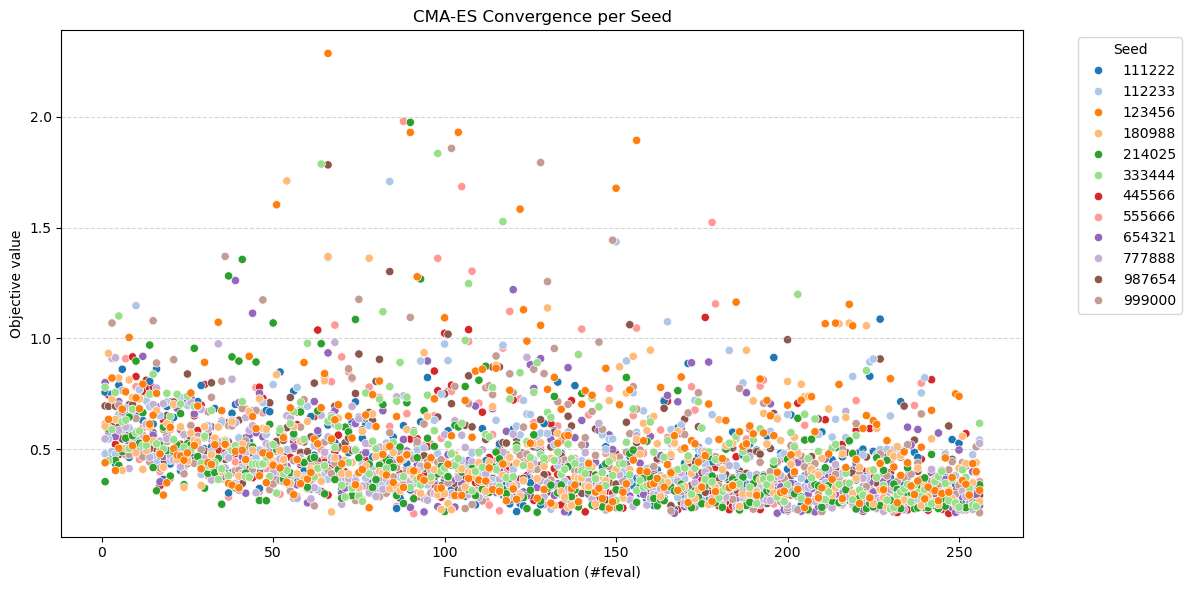

In [21]:
plot_data = []

for run in loaded_results:
    seed = run["seed"]
    history = run["history"]

    fevals = list(range(1, len(history["objective"]) + 1))  # #feval
    objectives = history["objective"]

    for f, obj in zip(fevals, objectives):
        plot_data.append({"seed": seed, "feval": f, "objective": obj})

df_plot = pd.DataFrame(plot_data)

# Plot
plt.figure(figsize=(12, 6))

sns.scatterplot(
    data=df_plot,
    x="feval",
    y="objective",
    hue="seed",
    marker="o",
    palette="tab20",  # can use any palette
)

plt.xlabel("Function evaluation (#feval)")
plt.ylabel("Objective value")
plt.title("CMA-ES Convergence per Seed")
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.legend(title="Seed", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

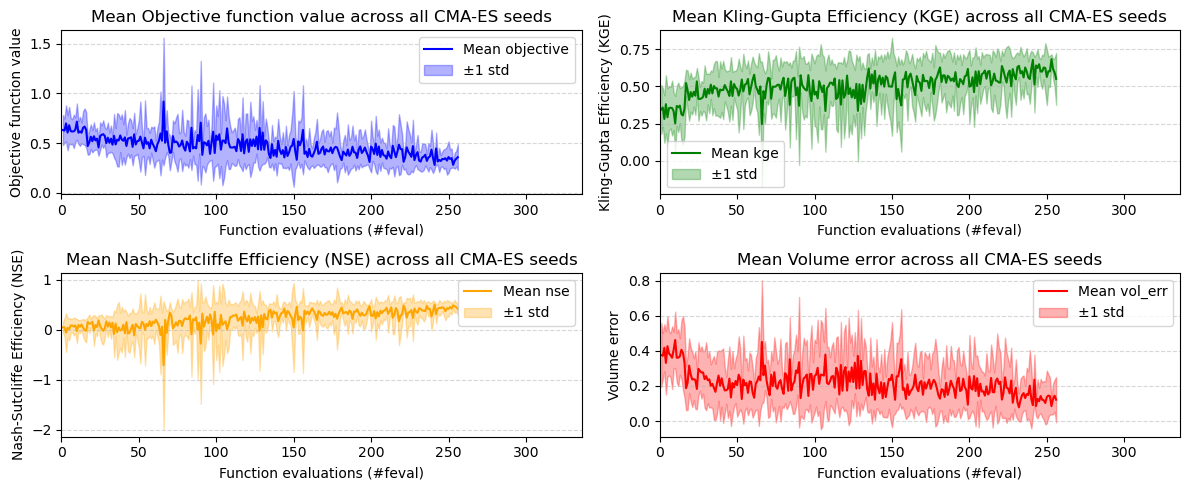

In [22]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

metrics = ["objective", "kge", "nse", "vol_err"]

# Mapping from metric key to long/descriptive name
metric_names = {
    "objective": "Objective function value",
    "kge": "Kling-Gupta Efficiency (KGE)",
    "nse": "Nash-Sutcliffe Efficiency (NSE)",
    "vol_err": "Volume error",
}

# Build DataFrame of all seeds and metrics
plot_data = []

for run in loaded_results:
    seed = run["seed"]
    history = run["history"]
    fevals = np.arange(1, len(history["objective"]) + 1)

    for f in fevals:
        row = {"seed": seed, "feval": f}
        for m in metrics:
            row[m] = history[m][f - 1]  # f-1 because fevals start at 1
        plot_data.append(row)

df_plot = pd.DataFrame(plot_data)

# Plot mean ± std for each metric
plt.figure(figsize=(12, 5))

colors = {"objective": "blue", "kge": "green", "nse": "orange", "vol_err": "red"}

for i, metric in enumerate(metrics, 1):
    plt.subplot(2, 2, i)

    df_summary = df_plot.groupby("feval")[metric].agg(["mean", "std"]).reset_index()

    plt.plot(df_summary["feval"], df_summary["mean"], color=colors[metric], label=f"Mean {metric}")
    plt.fill_between(
        df_summary["feval"],
        df_summary["mean"] - df_summary["std"],
        df_summary["mean"] + df_summary["std"],
        color=colors[metric],
        alpha=0.3,
        label="±1 std",
    )

    plt.xlabel("Function evaluations (#feval)")
    plt.ylabel(metric_names[metric])
    plt.title(f"Mean {metric_names[metric]} across all CMA-ES seeds")
    plt.grid(axis="y", linestyle="--", alpha=0.5)
    plt.legend()
    plt.xlim(0, 336)

plt.tight_layout()
plt.show()